In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_excel(r"C:\Users\USER\Documents\datasets\Sample-Superstore.xls")
print("Datasets Loaded Successfully")
print("Shape:", df.shape)

Datasets Loaded Successfully
Shape: (9994, 21)


         Total_sales  Total_profit  Profit_Margin
Region                                           
West       725457.82     108418.45          14.94
East       678781.24      91522.78          13.48
Central    501239.89      39706.36           7.92
South      391721.90      46749.43          11.93


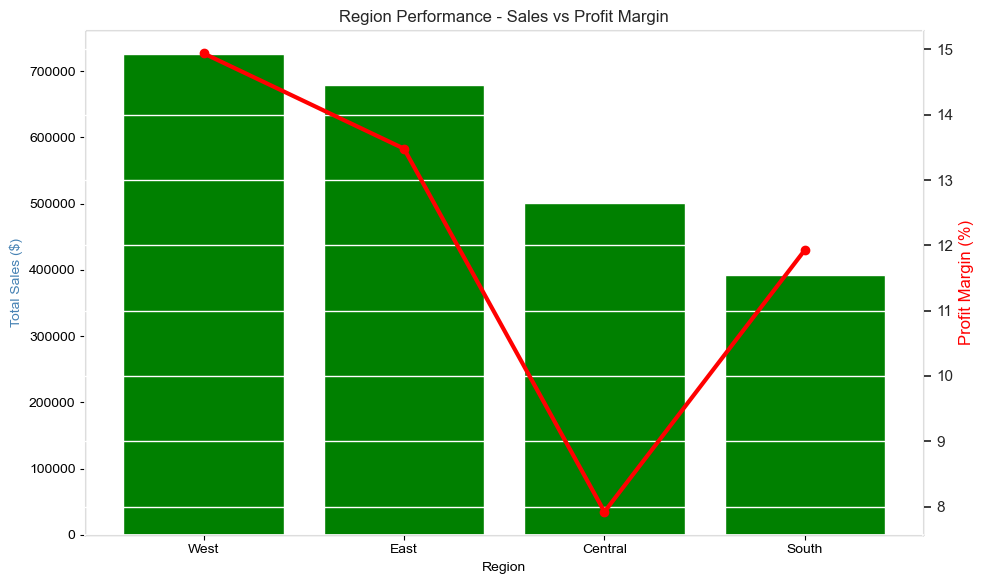

In [2]:
region_performance= df.groupby("Region").agg(
    Total_sales= ("Sales", "sum"),
    Total_profit= ("Profit", "sum")
)
region_performance["Profit_Margin"]= (region_performance["Total_profit"]/region_performance["Total_sales"]* 100)
region_performance= region_performance.sort_values("Total_sales", ascending= False).round(2)
print(region_performance)

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.set_theme(style= "darkgrid")
# Bar chart for Total Sales
ax1.bar(region_performance.index, region_performance["Total_sales"], 
        color="green", label="Total Sales")
ax1.set_xlabel("Region")
ax1.set_ylabel("Total Sales ($)", color="steelblue")

# Line chart for Profit Margin on second axis
ax2 = ax1.twinx()
ax2.plot(region_performance.index, region_performance["Profit_Margin"], 
         color="red", marker="o", linewidth=3, label="Profit Margin")
ax2.set_ylabel("Profit Margin (%)", color="red")

plt.title("Region Performance - Sales vs Profit Margin")
plt.tight_layout()
plt.show()

                              Total_profit
Category        Sub-Category              
Furniture       Chairs            26590.17
                Furnishings       13059.14
                Bookcases         -3472.56
                Tables           -17725.48
Office Supplies Paper             34053.57
                Binders           30221.76
                Storage           21278.83
                Appliances        18138.01
                Envelopes          6964.18
                Art                6527.79
                Labels             5546.25
                Fasteners           949.52
                Supplies          -1189.10
Technology      Copiers           55617.82
                Phones            44515.73
                Accessories       41936.64
                Machines           3384.76


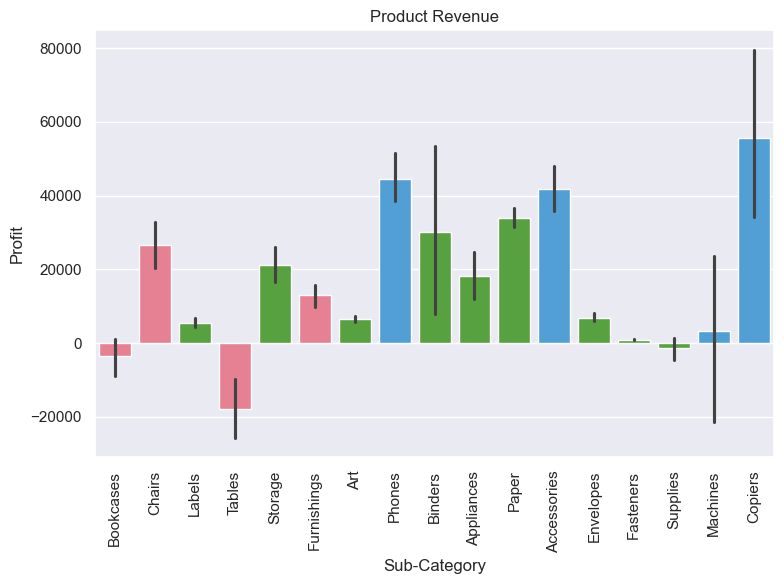

----------------------------------------------------------------------


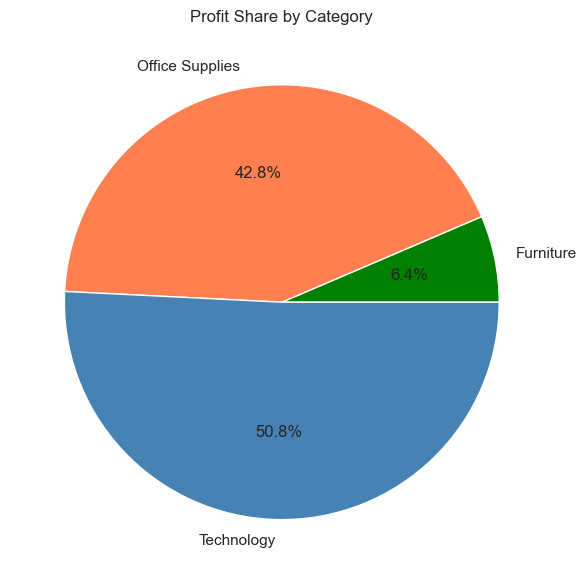

In [3]:
product_revenue= df.groupby(["Category", "Sub-Category"]).agg(
    Total_profit= ("Profit", "sum")
).round(2)

product_revenue= product_revenue.sort_values(
    ["Category", "Total_profit"], 
    ascending= [True, False]
)
        

print(product_revenue.to_string())

plt.figure(figsize= (8, 6))
sns.barplot(data=df, x="Sub-Category", y="Profit", estimator="sum", hue= "Category", legend= False, palette="husl")
plt.title("Product Revenue")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("-" * 70)

category_total = product_revenue.groupby("Category")["Total_profit"].sum()

plt.figure(figsize=(8, 6))
plt.pie(category_total.values,
        labels=category_total.index,
        autopct="%1.1f%%",
        colors=["green", "coral", "steelblue"])
plt.title("Profit Share by Category")
plt.tight_layout()
plt.show()
        







    

Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


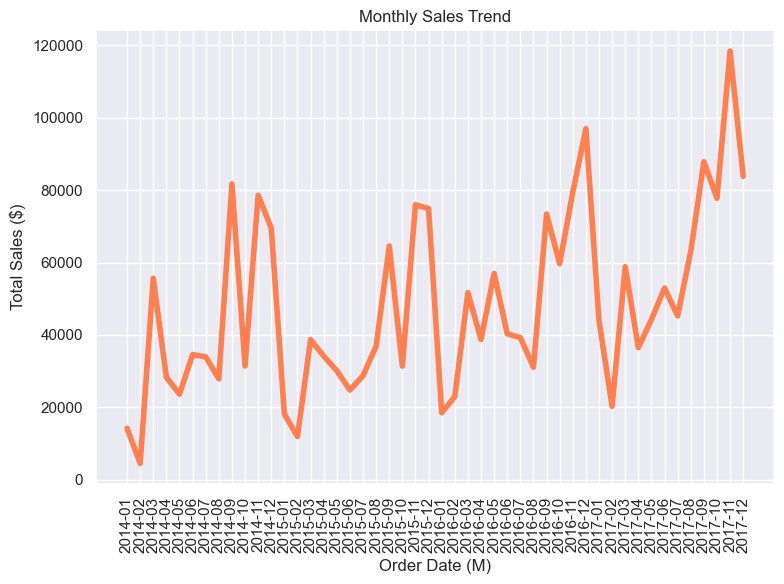

In [4]:
df["Order Date"]= pd.to_datetime(df["Order Date"]).dt.to_period("M")
Monthly_sales_trend= df.groupby("Order Date")["Sales"].sum()
print(Monthly_sales_trend)

plt.figure(figsize= (8, 6))
plt.plot(Monthly_sales_trend.index.astype(str), Monthly_sales_trend.values, color= "coral", linewidth= 4)
plt.xlabel("Order Date (M)")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend")
plt.xticks(rotation= 90)
plt.tight_layout()
plt.show()

Segment
Consumer       1161401.34
Corporate       706146.37
Home Office     429653.15
Name: Sales, dtype: float64


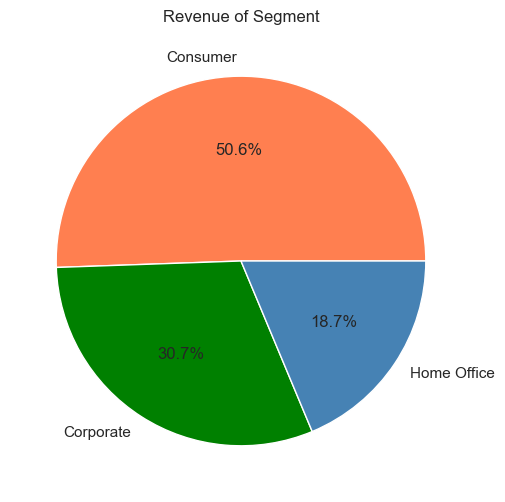

In [5]:
Segment_Revenue= df.groupby("Segment")["Sales"].sum().sort_values(ascending= False).round(2)
print(Segment_Revenue)

plt.figure(figsize= (8, 6))
plt.pie( Segment_Revenue.values, 
         labels= Segment_Revenue.index,
         autopct= "%1.1f%%",
         colors= ["coral", "green", "steelblue"]
       )
plt.title("Revenue of Segment")
plt.show()
        



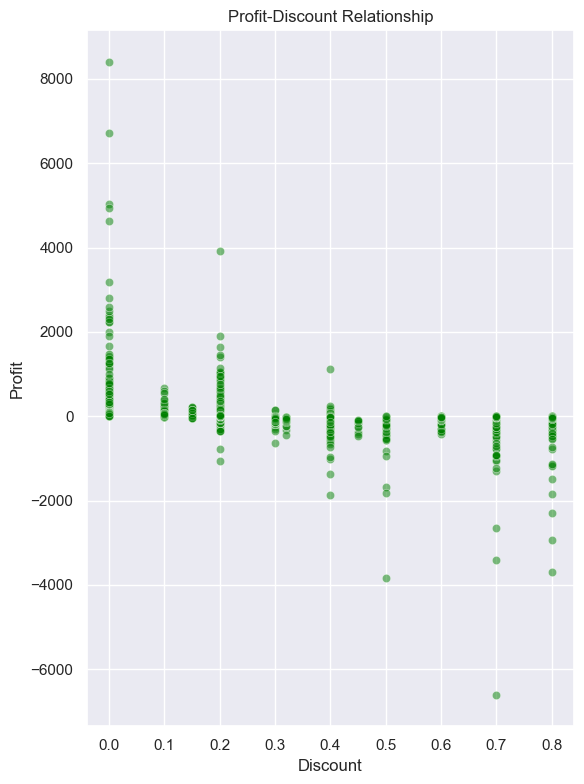

In [6]:
plt.figure(figsize= (6, 8))
sns.set_theme(style= "darkgrid")
sns.scatterplot(data= df,
                x= "Discount", y= "Profit", color= "green", alpha= 0.5)
plt.title("Profit-Discount Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

LARE PROJECTS
Datasets Loaded Successfully
Shape: (9994, 21)
----------------------------------------------------------------------
         Total_sales  Total_profit  Profit_Margin
Region                                           
West       725457.82     108418.45          14.94
East       678781.24      91522.78          13.48
Central    501239.89      39706.36           7.92
South      391721.90      46749.43          11.93


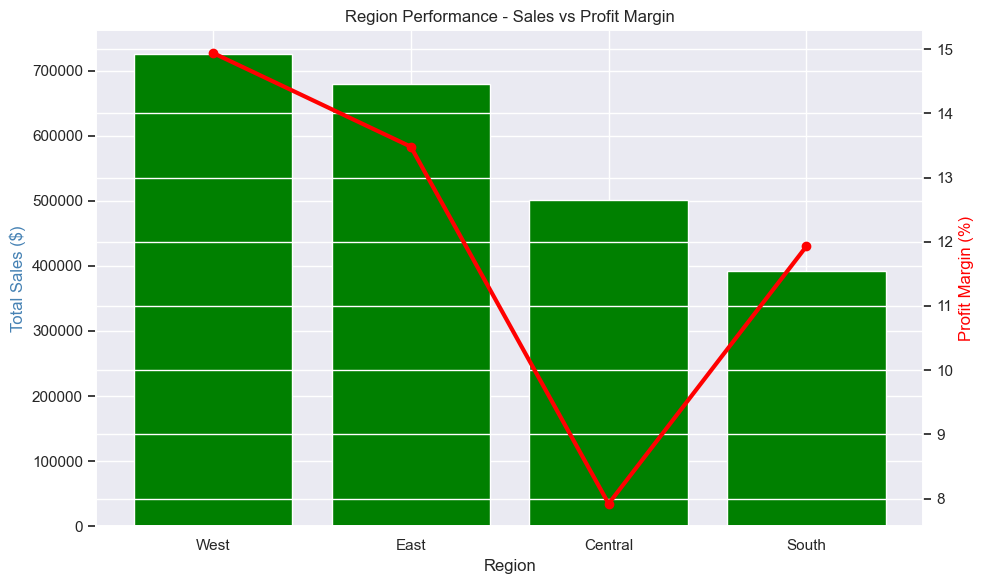

----------------------------------------------------------------------
                              Total_profit
Category        Sub-Category              
Furniture       Chairs            26590.17
                Furnishings       13059.14
                Bookcases         -3472.56
                Tables           -17725.48
Office Supplies Paper             34053.57
                Binders           30221.76
                Storage           21278.83
                Appliances        18138.01
                Envelopes          6964.18
                Art                6527.79
                Labels             5546.25
                Fasteners           949.52
                Supplies          -1189.10
Technology      Copiers           55617.82
                Phones            44515.73
                Accessories       41936.64
                Machines           3384.76


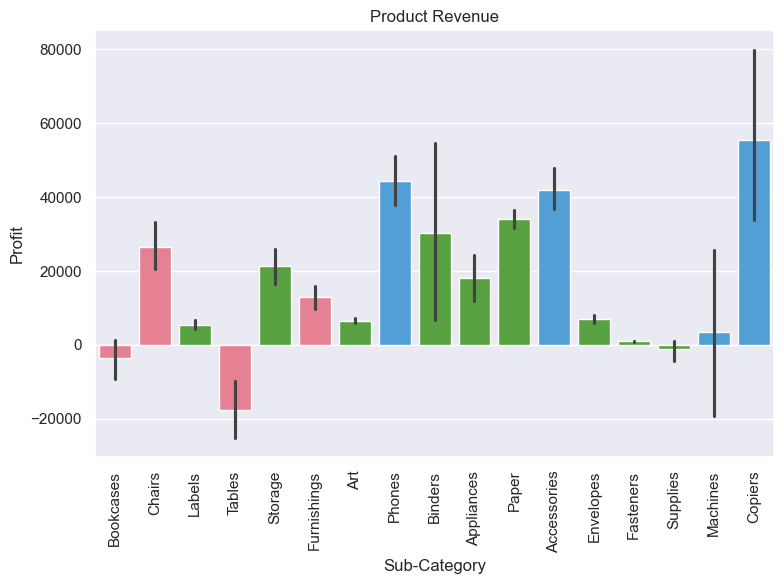

----------------------------------------------------------------------


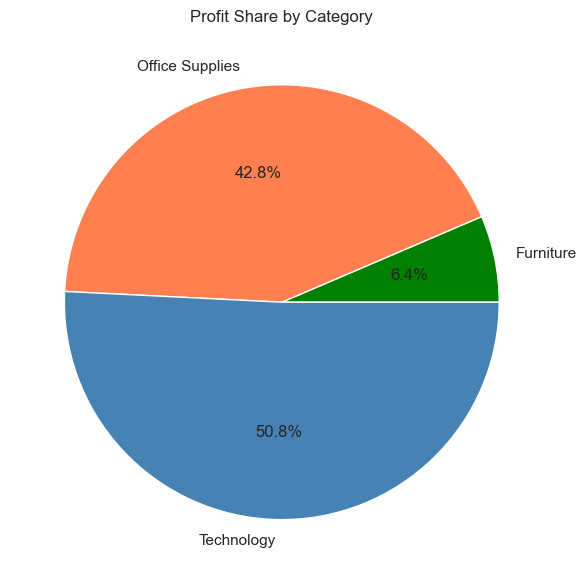

----------------------------------------------------------------------
Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.536

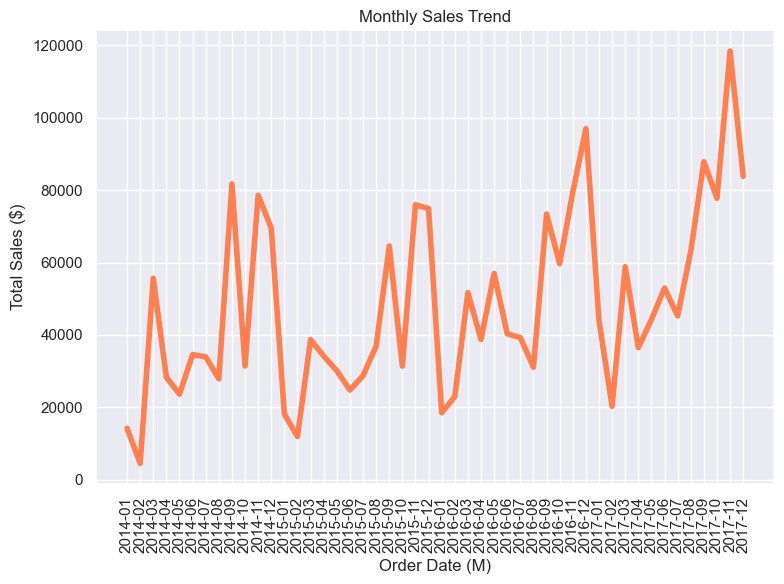

----------------------------------------------------------------------
Segment
Consumer       1161401.34
Corporate       706146.37
Home Office     429653.15
Name: Sales, dtype: float64


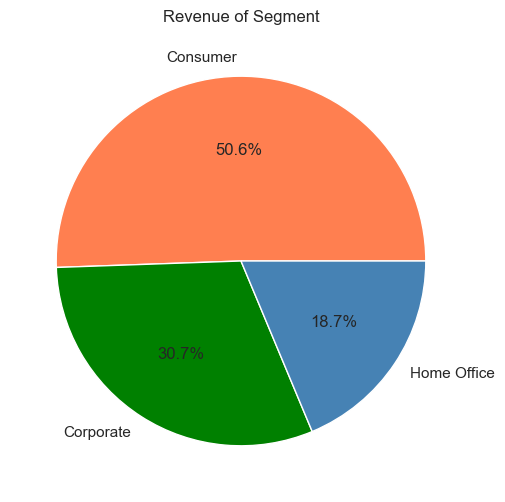

----------------------------------------------------------------------


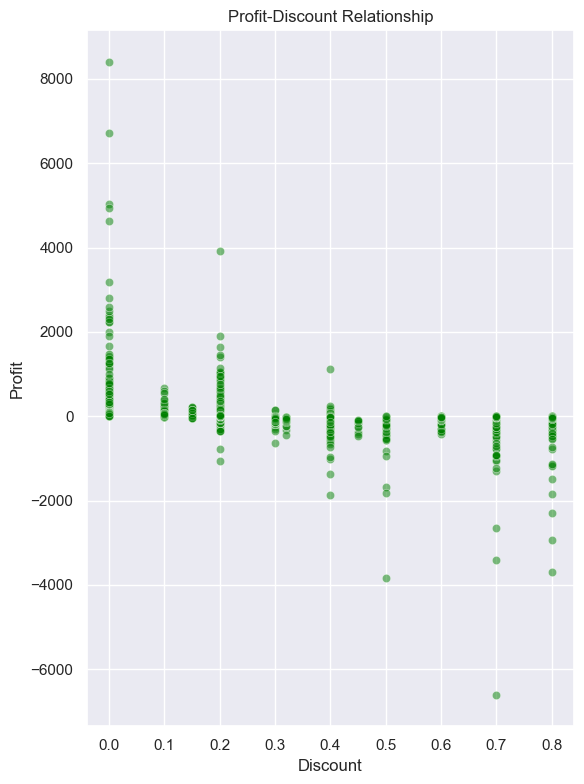

BUSINESS RECOMMENDATIONS
1. West region leads in sales and profit margin - invest more here
2. Central region has highest discounts and lowest margin - reduce discounting
3. Furniture category is barely profitable - review pricing strategy
4. Technology copiers are top profit drivers - prioritize in marketing
5. Consumer segment dominates - develop Corporate segment for growth
6. Heavy discounting hurts profit without meaningfully increasing sales


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_excel(r"C:\Users\USER\Documents\datasets\Sample-Superstore.xls")

print("LARE PROJECTS")
print("Datasets Loaded Successfully")
print("Shape:", df.shape)

print("-" * 70)

region_performance= df.groupby("Region").agg(
    Total_sales= ("Sales", "sum"),
    Total_profit= ("Profit", "sum")
)
region_performance["Profit_Margin"]= (region_performance["Total_profit"]/region_performance["Total_sales"]* 100)
region_performance= region_performance.sort_values("Total_sales", ascending= False).round(2)
print(region_performance)

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.set_theme(style= "darkgrid")
# Bar chart for Total Sales
ax1.bar(region_performance.index, region_performance["Total_sales"], 
        color="green", label="Total Sales")
ax1.set_xlabel("Region")
ax1.set_ylabel("Total Sales ($)", color="steelblue")

# Line chart for Profit Margin on second axis
ax2 = ax1.twinx()
ax2.plot(region_performance.index, region_performance["Profit_Margin"], 
         color="red", marker="o", linewidth=3, label="Profit Margin")
ax2.set_ylabel("Profit Margin (%)", color="red")

plt.title("Region Performance - Sales vs Profit Margin")
plt.tight_layout()
plt.show()

print("-" * 70)

product_revenue= df.groupby(["Category", "Sub-Category"]).agg(
    Total_profit= ("Profit", "sum")
).round(2)

product_revenue= product_revenue.sort_values(
    ["Category", "Total_profit"], 
    ascending= [True, False]
)
        

print(product_revenue.to_string())

plt.figure(figsize= (8, 6))
sns.barplot(data=df, x="Sub-Category", y="Profit", estimator="sum", hue= "Category", legend= False, palette="husl")
plt.title("Product Revenue")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("-" * 70)

category_total = product_revenue.groupby("Category")["Total_profit"].sum()

plt.figure(figsize=(8, 6))
plt.pie(category_total.values,
        labels=category_total.index,
        autopct="%1.1f%%",
        colors=["green", "coral", "steelblue"])
plt.title("Profit Share by Category")
plt.tight_layout()
plt.show()

print("-" * 70)

df["Order Date"]= pd.to_datetime(df["Order Date"]).dt.to_period("M")
Monthly_sales_trend= df.groupby("Order Date")["Sales"].sum()
print(Monthly_sales_trend)

plt.figure(figsize= (8, 6))
plt.plot(Monthly_sales_trend.index.astype(str), Monthly_sales_trend.values, color= "coral", linewidth= 4)
plt.xlabel("Order Date (M)")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend")
plt.xticks(rotation= 90)
plt.tight_layout()
plt.show()

print("-" * 70)

Segment_Revenue= df.groupby("Segment")["Sales"].sum().sort_values(ascending= False).round(2)
print(Segment_Revenue)

plt.figure(figsize= (8, 6))
plt.pie( Segment_Revenue.values, 
         labels= Segment_Revenue.index,
         autopct= "%1.1f%%",
         colors= ["coral", "green", "steelblue"]
       )
plt.title("Revenue of Segment")
plt.show()

print("-" * 70)

plt.figure(figsize= (6, 8))
sns.set_theme(style= "darkgrid")
sns.scatterplot(data= df,
                x= "Discount", y= "Profit", color= "green", alpha= 0.5)
plt.title("Profit-Discount Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

print("=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)
print("1. West region leads in sales and profit margin - invest more here")
print("2. Central region has highest discounts and lowest margin - reduce discounting")
print("3. Furniture category is barely profitable - review pricing strategy")
print("4. Technology copiers are top profit drivers - prioritize in marketing")
print("5. Consumer segment dominates - develop Corporate segment for growth")
print("6. Heavy discounting hurts profit without meaningfully increasing sales")
print("=" * 70)

    
